In [1]:
import sys
sys.path.append("../../src")
from kibble_zurek import *
from common_imports import *

In [13]:
def P_l(n,l,state, even = True):
    """
    P_n scales directly with the number of terms since even small odd sigma correlations need larger support to calcualte.
    Taking out odd terms works to make easier, but scaling is still 2^n.
    Minor improvements can still be had though.
    """
    #For most cases we use periodic boundary conditions
    #That said, watch out for this definition of indices
    indices = [i for i in range(0,n)]
    terms = all_combinations(indices)

    ###
    x_c = []
    for a in terms[1:]:
        a = np.array(a)
        a = np.append(a, -l)  # append spin at -l
        a = np.sort(a)
        x_c.append(tuple(a - a[0]))
    counter = Counter(x_c)
    # Extract vecs and counts as separate arrays/lists
    vecs = list(counter.keys())
    counts = np.array(list(counter.values()))

    ##
    dat = []

    for term in range(len(vecs)):
        indices = vecs[term]
        degen = counts[term]

        if len(indices)%2 == 1:
            if even ==True:
                dat.append(0)
            else:
                constant = len(k)//2
                indices = list(indices) + [x + constant for x in indices]
                dat.append(sqrt(np.abs(sigma_general(indices,U,k)))*degen)
        else:
            dat.append(sigma_general(indices,state)*degen)
    #Manually add the 1 
    dat.append(0)
    #All terms have equal weight. 
    return np.sum(dat)/2**n

In [2]:
loaded_states = np.load("data_KZ_L500_t0_N100_tau1.0e-03-3.2e+03.npz")
states = loaded_states['states']
taus = loaded_states['taus']

In [4]:
sigma_general([0,1],states[0])

np.complex128(0.027967142580192787+0j)

In [25]:
from joblib import Parallel, delayed
import numpy as np
import matplotlib.pyplot as plt

r_vals = np.arange(1, 101)
n_vals = range(1, 7)
js = range(len(taus))

def compute_P_l_for_state(j):
    results = np.zeros((len(n_vals), len(r_vals)))
    for n_idx, n in enumerate(n_vals):
        dat = Parallel(n_jobs=-1)(
            delayed(P_l)(n, r, states[j]) for r in r_vals
        )
        results[n_idx] = dat
    return results

# compute for all states
all_results = [compute_P_l_for_state(j) for j in js]

# convert to array: shape (len(taus), 6, len(r_vals))
all_results = np.array(all_results)

# optional: save
np.save("data_P_l_all.npy", all_results)

/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: divide by zero encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: overflow encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: divide by zero encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: overflow encountered in det
  r = _umath_linalg.det(a, signature=sign

(0.0, 40.0)

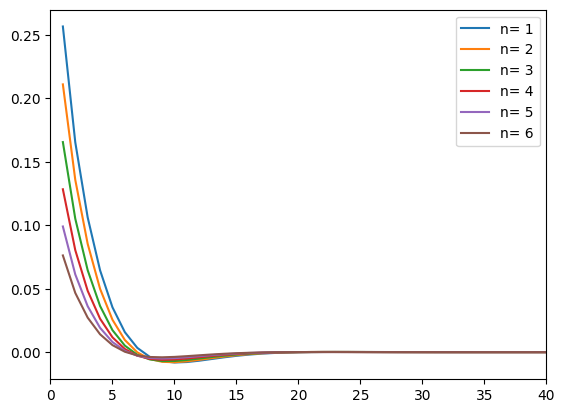

In [40]:
for i in range(6):
    plot(r_vals,(all_results[len(taus)//2][i][:]),label=f"n= {i+1}")
legend()
xlim(0,40)

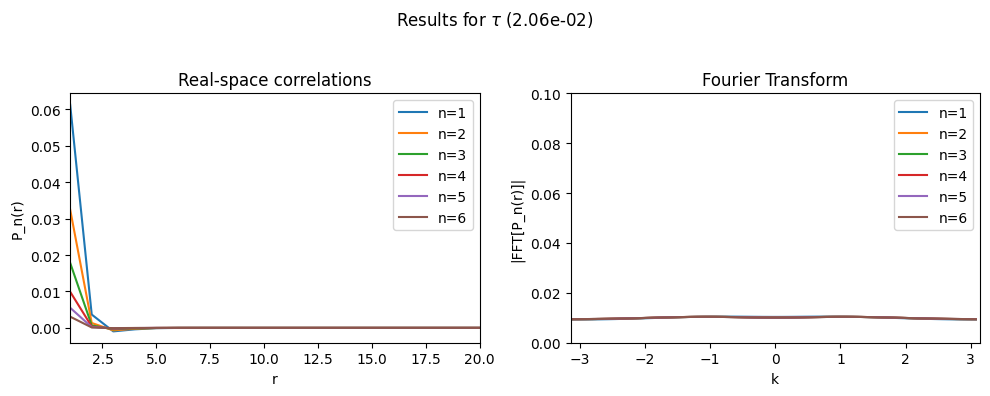

In [106]:
Q = 20 # choose which tau index to plot

plt.figure(figsize=(10,4))

# real-space correlations
plt.subplot(1,2,1)
for i in range(6):
    plt.plot(r_vals, (all_results[Q][i]), label=f"n={i+1}")
plt.legend()
plt.xlim(1,max(r_vals))
#ylim(-.1,0)
plt.xlabel("r")
plt.ylabel("P_n(r)")
xlim(1,20)
#loglog()
plt.title("Real-space correlations")

# Fourier transforms
plt.subplot(1,2,2)
for i in range(6):
    y = all_results[Q][i]
    yk = np.fft.fftshift(np.abs(np.fft.fft(y)))
    k = np.fft.fftshift(np.fft.fftfreq(len(y), d=1))*2*pi
    plt.plot(k, yk/sum((yk)), label=f"n={i+1}")
plt.legend()
plt.xlabel("k")
ylim(0,.1)
xlim(-pi,pi)
#xlim(k[1]-k[0],3.14)
#loglog()
plt.ylabel("|FFT[P_n(r)]|")
plt.title("Fourier Transform")

plt.suptitle(fr"Results for $\tau$ ({taus[Q]:.2e})")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: divide by zero encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: overflow encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.a

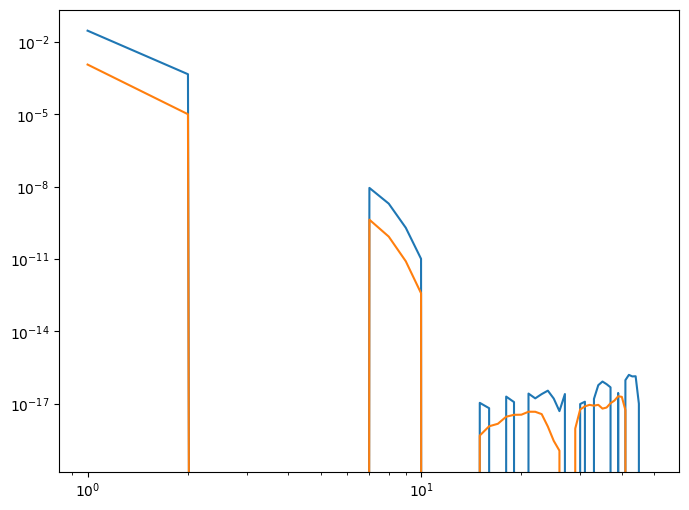

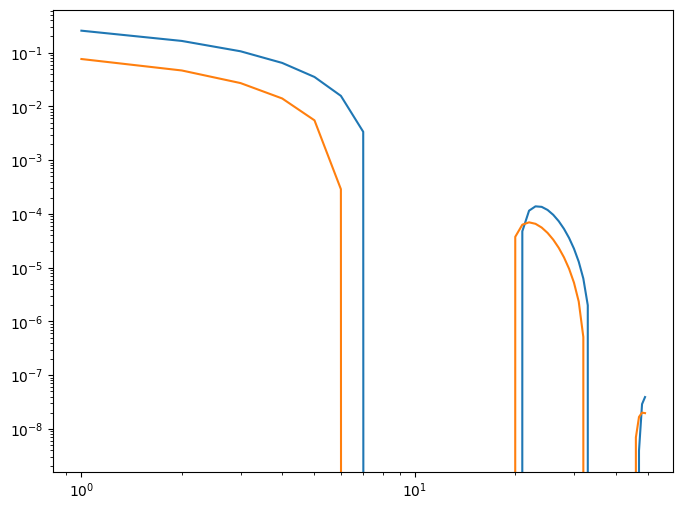

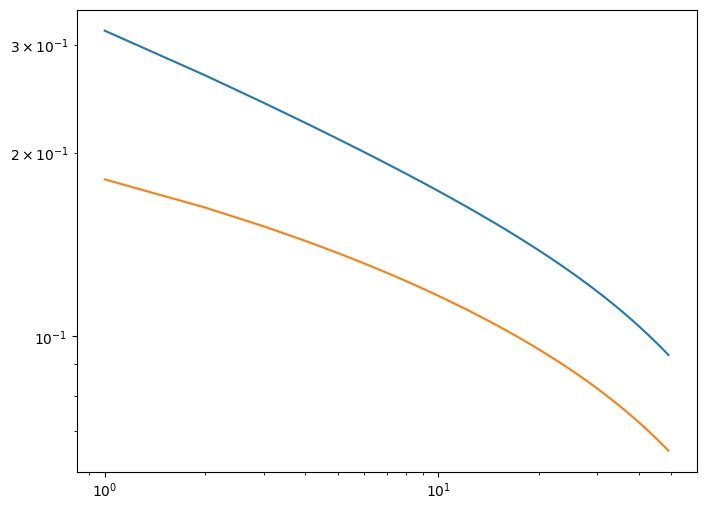

In [24]:
js = [10,len(taus)//2,-1]

for j in js:
    plt.figure(figsize=(8,6))
    r = np.arange(1,50)
    dat = [P_l(1,i,states[j]) for i in r]
    dat2= [P_l(6,i,states[j]) for i in r]
    plot(r,dat)
    plot(r,dat2)
    loglog()
    show()
